In [1]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Get Python executable path and add lib directory to PYTHONPATH
import sys
import os

python_exec_dir = os.path.dirname(os.path.dirname(sys.executable))
lib_path = os.path.join(python_exec_dir, 'lib')

if lib_path not in sys.path:
    sys.path.append(lib_path)
    print(f"Added {lib_path} to PYTHONPATH")


Added /home/gmacmillan/mambaforge/envs/real-time-occupancy/lib to PYTHONPATH


In [2]:
# Utility function to safely release camera resources
def release_camera(cap):
    if cap is not None:
        cap.release()
    cv2.destroyAllWindows()


In [3]:
def test_webcam(camera_id=0, test_duration=5):
    """
    Test webcam functionality and display basic properties
    Args:
        camera_id (int): Camera device ID (usually 0 for primary webcam)
        test_duration (int): How long to keep the camera open in seconds
    """
    try:
        # Initialize camera
        cap = cv2.VideoCapture(camera_id)
        
        if not cap.isOpened():
            raise Exception(f"Could not open camera {camera_id}")
            
        # Get and print camera properties
        width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)
        height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
        fps = cap.get(cv2.CAP_PROP_FPS)
        
        print(f"Camera Properties:")
        print(f"Resolution: {width}x{height}")
        print(f"FPS: {fps}")
        
        # Capture and display a single frame
        ret, frame = cap.read()
        if ret:
            # Convert BGR to RGB for matplotlib
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(10, 8))
            plt.imshow(frame_rgb)
            plt.axis('off')
            plt.title('Test Frame from Webcam')
            plt.show()
            
            # Test real-time display
            print("\nStarting real-time display test...")
            start_time = time.time()
            frames_captured = 0
            
            while (time.time() - start_time) < test_duration:
                ret, frame = cap.read()
                if ret:
                    frames_captured += 1
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    clear_output(wait=True)
                    plt.figure(figsize=(10, 8))
                    plt.imshow(frame_rgb)
                    plt.axis('off')
                    plt.title(f'Live Feed (Frame {frames_captured})')
                    plt.show()
                    
            actual_fps = frames_captured / test_duration
            print(f"\nTest completed!")
            print(f"Actual FPS achieved: {actual_fps:.2f}")
            
    except Exception as e:
        print(f"Error: {str(e)}")
    finally:
        release_camera(cap)


In [4]:
def list_available_cameras(max_cameras=10):
    """
    List all available camera devices
    Args:
        max_cameras (int): Maximum number of camera indices to test
    """
    available_cameras = []
    for i in range(max_cameras):
        cap = cv2.VideoCapture(i)
        if cap.isOpened():
            ret, _ = cap.read()
            if ret:
                available_cameras.append(i)
            cap.release()
    return available_cameras

# Test camera listing
print("Scanning for available cameras...")
available_cameras = list_available_cameras()
print(f"Available camera indices: {available_cameras}")

# Test the primary webcam
print("\nTesting primary webcam...")
test_webcam(camera_id=0)

Scanning for available cameras...


[ WARN:0@4.335] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@4.454] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
[ WARN:0@4.454] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ERROR:0@4.457] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
[ WARN:0@4.624] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
[ERROR:0@4.626] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
[ WARN:0@5.129] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video5): can't open camera by index
[ERROR:0@5.130] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


Available camera indices: [2, 4, 6]

Testing primary webcam...
Error: Could not open camera 0


[ WARN:0@6.072] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video7): can't open camera by index
[ERROR:0@6.075] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
[ WARN:0@6.075] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video8): can't open camera by index
[ERROR:0@6.077] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
[ WARN:0@6.078] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video9): can't open camera by index
[ERROR:0@6.080] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range
[ WARN:0@6.087] global cap_v4l.cpp:913 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@6.089] global obsensor_uvc_stream_channel.cpp:158 getStreamChannelGroup Camera index out of range


In [3]:
top_level_dir_path = os.path.dirname(os.getcwd())
if top_level_dir_path not in sys.path:
    sys.path.append(top_level_dir_path)
# For RealSense camera testing
try:
    import pyrealsense2 as rs
    REALSENSE_AVAILABLE = True
except ImportError:
    REALSENSE_AVAILABLE = False
    print("Intel RealSense SDK not installed. Install with:")
    print("pip install pyrealsense2")


In [4]:
def test_realsense():
    """
    Test Intel RealSense camera functionality
    """
    if not REALSENSE_AVAILABLE:
        return
    
    try:
        # Configure depth and color streams
        pipeline = rs.pipeline()
        config = rs.config()
        
        # Get device product line for setting a supporting resolution
        pipeline_wrapper = rs.pipeline_wrapper(pipeline)
        pipeline_profile = config.resolve(pipeline_wrapper)
        device = pipeline_profile.get_device()
        device_product_line = str(device.get_info(rs.camera_info.product_line))
        
        print(f"RealSense Device Found: {device_product_line}")
        
        # Enable streams
        config.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
        config.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
        
        # Start streaming
        pipeline.start(config)
        
        try:
            # Wait for a coherent pair of frames
            frames = pipeline.wait_for_frames()
            depth_frame = frames.get_depth_frame()
            color_frame = frames.get_color_frame()
            
            if not depth_frame or not color_frame:
                raise Exception("Failed to get frames")
                
            # Convert images to numpy arrays
            depth_image = np.asanyarray(depth_frame.get_data())
            color_image = np.asanyarray(color_frame.get_data())
            
            # Apply colormap on depth image
            depth_colormap = cv2.applyColorMap(
                cv2.convertScaleAbs(depth_image, alpha=0.03), 
                cv2.COLORMAP_JET
            )
            
            # Show images
            plt.figure(figsize=(15, 5))
            
            plt.subplot(121)
            plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
            plt.title('RGB Image')
            plt.axis('off')
            
            plt.subplot(122)
            plt.imshow(depth_colormap)
            plt.title('Depth Image')
            plt.axis('off')
            
            plt.show()
            
        finally:
            pipeline.stop()
            
    except Exception as e:
        print(f"Error testing RealSense camera: {str(e)}")



Testing RealSense camera...
RealSense Device Found: D400


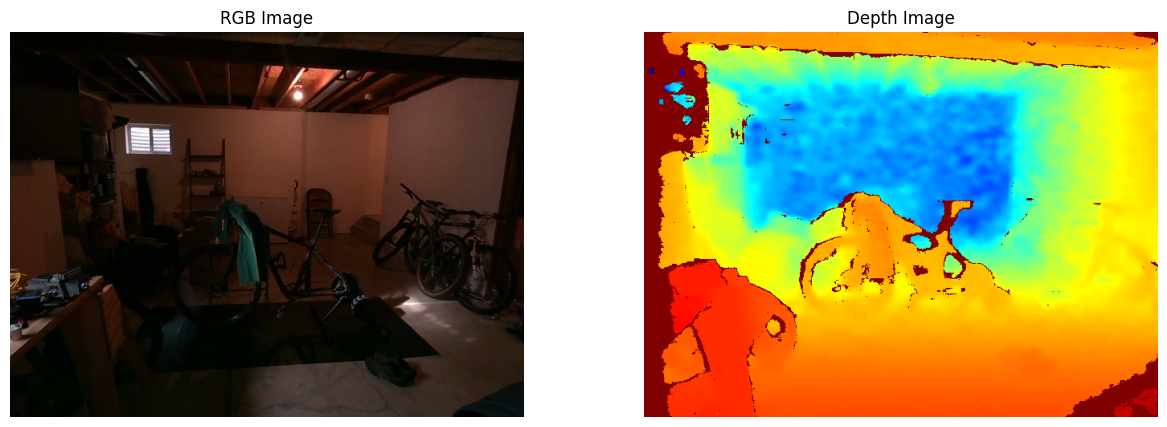

In [5]:
# Only run RealSense test if available
if REALSENSE_AVAILABLE:
    print("\nTesting RealSense camera...")
    test_realsense()

In [6]:
def test_realsense_with_filters(
    resolution=(640, 480),
    fps=30,
    enable_infrared=False,
    align_depth=True,
    filters=None
):
    """
    Test Intel RealSense camera functionality with configurable filters
    Args:
        resolution (tuple): Width and height
        fps (int): Frames per second
        enable_infrared (bool): Enable IR stream
        align_depth (bool): Align depth to color frame
        filters (dict): Post-processing filters configuration
    """
    if not REALSENSE_AVAILABLE:
        return
    
    try:
        # Configure streams
        pipeline = rs.pipeline()
        config = rs.config()
        
        # Get device info
        pipeline_wrapper = rs.pipeline_wrapper(pipeline)
        pipeline_profile = config.resolve(pipeline_wrapper)
        device = pipeline_profile.get_device()
        device_product_line = str(device.get_info(rs.camera_info.product_line))
        
        print(f"RealSense Device Found: {device_product_line}")
        
        # Enable streams
        config.enable_stream(rs.stream.depth, resolution[0], resolution[1], rs.format.z16, fps)
        config.enable_stream(rs.stream.color, resolution[0], resolution[1], rs.format.bgr8, fps)
        
        if enable_infrared:
            config.enable_stream(rs.stream.infrared, resolution[0], resolution[1], rs.format.y8, fps)
        
        # Start streaming
        profile = pipeline.start(config)
        
        # Setup filters
        filters = filters or {}
        filter_objects = {}
        if filters:
            print("\nConfigured filters:")
            if filters.get('decimation'):
                decimation = rs.decimation_filter()
                decimation.set_option(rs.option.filter_magnitude, filters['decimation'])
                filter_objects['decimation'] = decimation
                print(f"- Decimation (magnitude: {filters['decimation']})")
                
            if filters.get('spatial'):
                spatial = rs.spatial_filter()
                filter_objects['spatial'] = spatial
                print("- Spatial smoothing")
                
            if filters.get('temporal'):
                temporal = rs.temporal_filter()
                filter_objects['temporal'] = temporal
                print("- Temporal smoothing")
                
            if filters.get('hole_filling'):
                hole_filling = rs.hole_filling_filter()
                filter_objects['hole_filling'] = hole_filling
                print("- Hole filling")
        
        # Create align object if requested
        align = rs.align(rs.stream.color) if align_depth else None
        if align_depth:
            print("\nDepth alignment: Enabled")
        
        try:
            # Get and display frames
            for i in range(30):  # Show 30 frames
                frames = pipeline.wait_for_frames()
                
                if align:
                    frames = align.process(frames)
                
                depth_frame = frames.get_depth_frame()
                color_frame = frames.get_color_frame()
                
                # Apply filters to depth frame
                filtered_depth = depth_frame
                for filter_name, filter_obj in filter_objects.items():
                    filtered_depth = filter_obj.process(filtered_depth)
                
                if not filtered_depth or not color_frame:
                    continue
                
                # Convert images to numpy arrays
                depth_image = np.asanyarray(filtered_depth.get_data())
                color_image = np.asanyarray(color_frame.get_data())
                
                # Apply colormap on depth image
                depth_colormap = cv2.applyColorMap(
                    cv2.convertScaleAbs(depth_image, alpha=0.03), 
                    cv2.COLORMAP_JET
                )
                
                # Show images
                clear_output(wait=True)
                plt.figure(figsize=(15, 5))
                
                plt.subplot(121)
                plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
                plt.title('RGB Image')
                plt.axis('off')
                
                plt.subplot(122)
                plt.imshow(depth_colormap)
                plt.title('Depth Image (Filtered)')
                plt.axis('off')
                
                plt.show()
                time.sleep(0.1)  # Small delay to make display visible
                
        finally:
            pipeline.stop()
            
    except Exception as e:
        print(f"Error testing RealSense camera: {str(e)}")



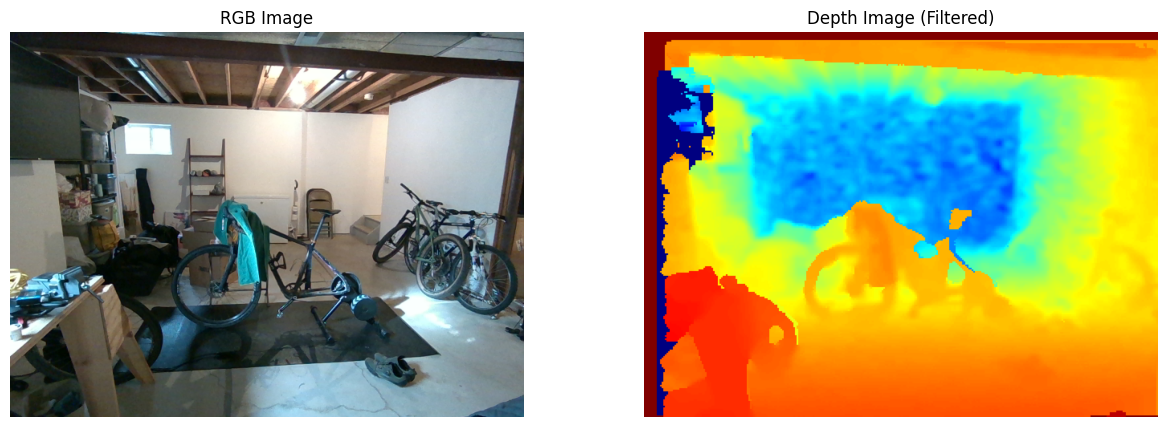

In [7]:
# Test with the same settings as the service
print("\nTesting RealSense camera with service configuration...")
test_realsense_with_filters(
    resolution=(640, 480),
    fps=30,
    enable_infrared=False,
    align_depth=True,
    filters={
        'decimation': 2,
        'spatial': True,
        'temporal': True,
        'hole_filling': True
    }
)